In [1]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.dates import MonthLocator, DateFormatter

from scipy import stats
pd.set_option("display.max_columns",200)

In [5]:
transactiondata=pd.read_excel("D:/quantium chips/QVI_transaction_data.xlsx")

In [7]:
customers=pd.read_csv(r"D:\quantium chips\QVI_purchase_behaviour.csv")

In [9]:
transactiondata.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836.000000,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,43464.036260,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
std,105.389282,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226
min,43282.000000,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,43373.000000,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,43464.000000,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,43555.000000,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,43646.000000,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000


In [17]:
transactiondata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [19]:
customers.describe()

,LYLTY_CARD_NBR
count,7.263700e+04
mean,1.361859e+05
std,8.989293e+04
min,1.000000e+03
25%,6.620200e+04
50%,1.340400e+05
75%,2.033750e+05
max,2.373711e+06


In [21]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [11]:
## 改日期规范
transactiondata["DATE"]=pd.to_datetime(transactiondata["DATE"],unit="D",origin="1899-12-30")

In [25]:
transactiondata.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [27]:
transactiondata["PROD_NAME"].describe()
transactiondata["PROD_NAME"].value_counts()

PROD_NAME
Kettle Mozzarella   Basil & Pesto 175g      3304
Kettle Tortilla ChpsHny&Jlpno Chili 150g    3296
Cobs Popd Swt/Chlli &Sr/Cream Chips 110g    3269
Tyrrells Crisps     Ched & Chives 165g      3268
Cobs Popd Sea Salt  Chips 110g              3265
                                            ... 
RRD Pc Sea Salt     165g                    1431
Woolworths Medium   Salsa 300g              1430
NCC Sour Cream &    Garden Chives 175g      1419
French Fries Potato Chips 175g              1418
WW Crinkle Cut      Original 175g           1410
Name: count, Length: 114, dtype: int64

In [13]:
unique_name=transactiondata["PROD_NAME"].unique()
word=[]
for name in unique_name:
    word.extend(str(name).split())
proword=pd.Series(word,name="word") 
nodigit=~proword.str.contains("\d",regex=True)
onlyal=proword.str.fullmatch("[A-Za-z]+").fillna(False)
clean_word=proword[nodigit&onlyal].str.upper()
word_fre=clean_word.value_counts()
word_fre.columns=["word","fre"]

<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
C:\Users\jueyo\AppData\Local\Temp\ipykernel_26444\662421832.py:6: SyntaxWarning: invalid escape sequence '\d'
  nodigit=~proword.str.contains("\d",regex=True)


In [15]:
word_fre.head(50)

word
CHIPS         21
SMITHS        16
CRINKLE       14
CUT           14
KETTLE        13
SALT          12
CHEESE        12
ORIGINAL      10
DORITOS        9
CHIP           9
SALSA          9
CORN           8
PRINGLES       8
RRD            8
CHICKEN        7
WW             7
SEA            6
SOUR           6
THINLY         5
CRISPS         5
VINEGAR        5
THINS          5
CHILLI         5
SUPREME        4
DELI           4
ROCK           4
RED            4
CREAM          4
NATURAL        4
INFUZIONS      4
MILD           3
OLD            3
DIP            3
TOSTITOS       3
TOMATO         3
CCS            3
PASO           3
EL             3
TORTILLA       3
SOY            3
COBS           3
POPD           3
TWISTIES       3
LIME           3
WOOLWORTHS     3
SENSATIONS     3
SWEET          3
SWT            2
FRENCH         2
CHIPCO         2
Name: count, dtype: int64

In [17]:
make_sa=transactiondata["PROD_NAME"].str.lower().str.contains("salsa",na=False)
make_dip=transactiondata["PROD_NAME"].str.lower().str.contains("dip",na=False)
transactiondata=transactiondata.loc[~(make_sa&make_dip)].copy()
transactiondata.shape

(255512, 8)

In [74]:
# outlier
transactiondata.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,255512,255512.000000,2.555120e+05,2.555120e+05,255512.000000,255512.000000,255512.000000
mean,2018-12-30 02:05:04.442844160,135.069715,1.355385e+05,1.351492e+05,56.445729,1.907225,7.215434
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,2018-09-30 00:00:00,70.000000,7.003075e+04,6.766875e+04,28.000000,2.000000,5.400000
50%,2018-12-30 00:00:00,130.000000,1.303540e+05,1.351235e+05,53.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.000000,2.030782e+05,2.026292e+05,86.000000,2.000000,8.800000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000
std,NaN,76.751389,8.054947e+04,7.810313e+04,33.405874,0.652135,3.085918


In [76]:
transactiondata["PROD_QTY"].sort_values(ascending=False).head()

69762     200
69763     200
117895      5
117968      5
117935      5
Name: PROD_QTY, dtype: int64

In [19]:
outliers=transactiondata.loc[transactiondata["PROD_QTY"]==200].copy()
if len(outliers)>0:
    card=outliers["LYLTY_CARD_NBR"].unique()
    transactiondata=transactiondata.loc[~transactiondata["LYLTY_CARD_NBR"].isin(card)].copy()

In [21]:
transaction_by_day=(transactiondata.groupby("DATE").size().rename("N").reset_index().sort_values("DATE"))
full_day=pd.date_range("2018-07-01","2019-06-30",freq="D")
transaction_full=(pd.DataFrame({"DATE":full_day}).merge(transaction_by_day,on="DATE",how="left").fillna({"N":0}))

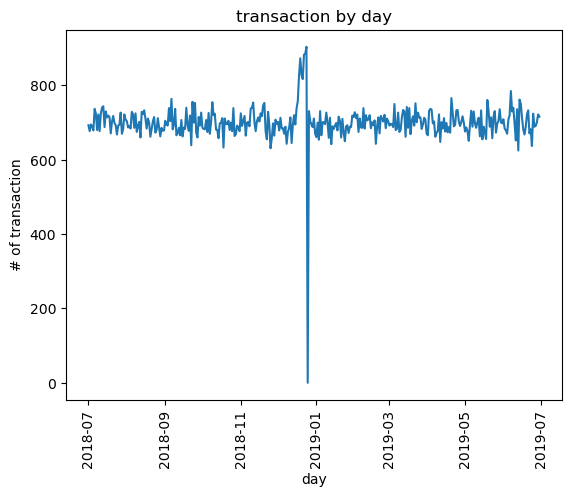

In [102]:
plt.figure()
plt.plot(transaction_full["DATE"],transaction_full["N"])
plt.title("transaction by day")
plt.xlabel("day")
plt.ylabel("# of transaction")
plt.xticks(rotation=90)
plt.show()

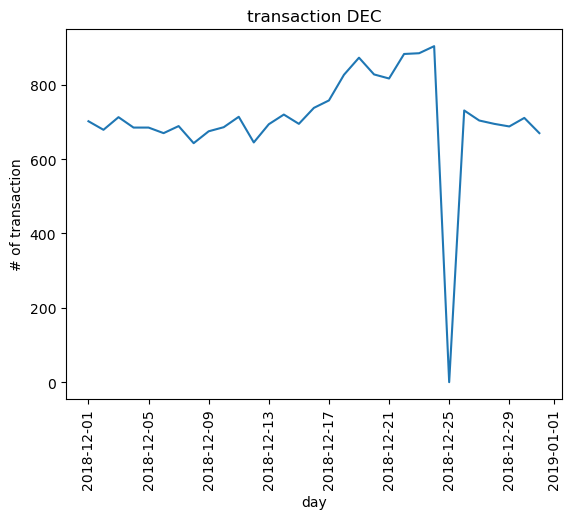

In [23]:
dec=transaction_full.loc[(transaction_full["DATE"]>="2018-12-01")&(transaction_full["DATE"]<="2018-12-31")]
plt.figure()
plt.plot(dec["DATE"],dec["N"])
plt.title("transaction DEC")
plt.xlabel("day")
plt.ylabel("# of transaction")
plt.xticks(rotation=90)
plt.show()

In [ ]:
# 骤减是因为圣诞节

In [25]:
transactiondata["pack_size"]=transactiondata["PROD_NAME"].str.extract(r"(\d+)",expand=False).astype(float)
pack_count=(transactiondata.groupby("pack_size").size().rename("N").reset_index().sort_values("pack_size"))

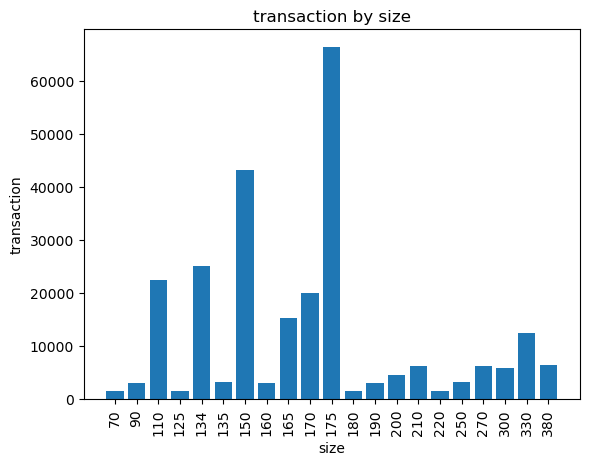

In [116]:
plt.figure()
plt.bar(pack_count["pack_size"].astype(int).astype(str),pack_count["N"])
plt.title("transaction by size")
plt.xlabel("size")
plt.ylabel("transaction")
plt.xticks(rotation=90)
plt.show()

In [27]:
transactiondata["brand"]=transactiondata["PROD_NAME"].astype(str).str.split().str[0].str.upper()
transactiondata["brand"].value_counts().head(50)

brand
KETTLE        41288
SMITHS        28860
PRINGLES      25102
DORITOS       24962
THINS         14075
RRD           11894
INFUZIONS     11057
WW            10320
COBS           9693
TOSTITOS       9471
TWISTIES       9454
TYRRELLS       6442
GRAIN          6272
NATURAL        6050
RED            5885
CHEEZELS       4603
CCS            4551
WOOLWORTHS     4437
DORITO         3183
INFZNS         3144
SMITH          2963
CHEETOS        2927
SNBTS          1576
BURGER         1564
GRNWVES        1468
SUNBITES       1432
NCC            1419
FRENCH         1418
Name: count, dtype: int64

In [29]:
brand_map = {
    "DORITO": "DORITOS",
    "SMITH": "SMITHS",
    "WOOLWORTHS": "WOOLWORTHS",
    "WW": "WOOLWORTHS",
    "INFZNS": "INFUZIONS",
    "RED": "RRD",   # 如果你决定用 RRD 代表 Red Rock Deli
    # 下面这些要通过反查 PROD_NAME 确认后再合并（先别乱合并）
    # "SNBTS": "SUNBITES",
    # "GRNWVES": "GRAINWAVES",
    # "NCC": "...",
    # "CCS": "...",
}

transactiondata["brand"] = transactiondata["brand"].replace(brand_map)
transactiondata["brand"].value_counts().head(30)

brand
KETTLE        41288
SMITHS        31823
DORITOS       28145
PRINGLES      25102
RRD           17779
WOOLWORTHS    14757
INFUZIONS     14201
THINS         14075
COBS           9693
TOSTITOS       9471
TWISTIES       9454
TYRRELLS       6442
GRAIN          6272
NATURAL        6050
CHEEZELS       4603
CCS            4551
CHEETOS        2927
SNBTS          1576
BURGER         1564
GRNWVES        1468
SUNBITES       1432
NCC            1419
FRENCH         1418
Name: count, dtype: int64

In [31]:
data=transactiondata.merge(customers,on="LYLTY_CARD_NBR",how="left")
data[["LIFESTAGE","PREMIUM_CUSTOMER"]].isna().sum()

LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [35]:
data["unit_price"]=data["TOT_SALES"]/data["PROD_QTY"]
segments=["LIFESTAGE","PREMIUM_CUSTOMER"]
sales=data.groupby(segments)["TOT_SALES"].sum().reset_index(name="total_sales")
pivot=sales.pivot(index="LIFESTAGE",columns="PREMIUM_CUSTOMER",values="total_sales")

<Figure size 640x480 with 0 Axes>

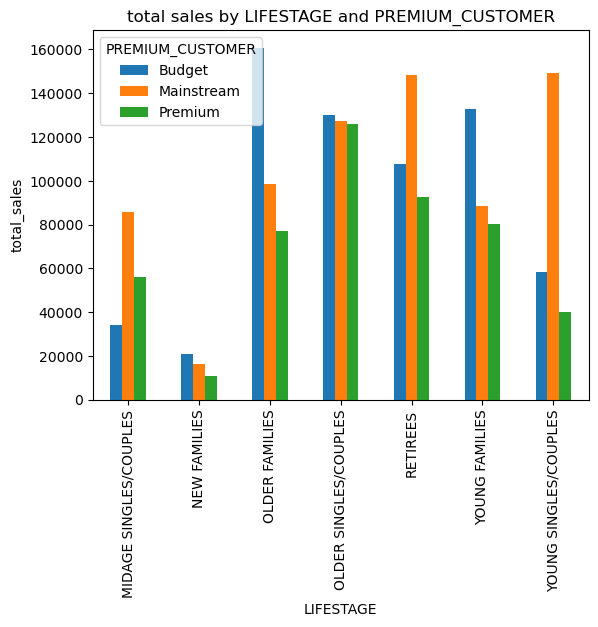

In [138]:
plt.figure()
pivot.plot(kind="bar")
plt.title("total sales by LIFESTAGE and PREMIUM_CUSTOMER")
plt.xlabel("LIFESTAGE")
plt.ylabel("total_sales")
plt.xticks(rotation=90)
plt.show()

<Figure size 640x480 with 0 Axes>

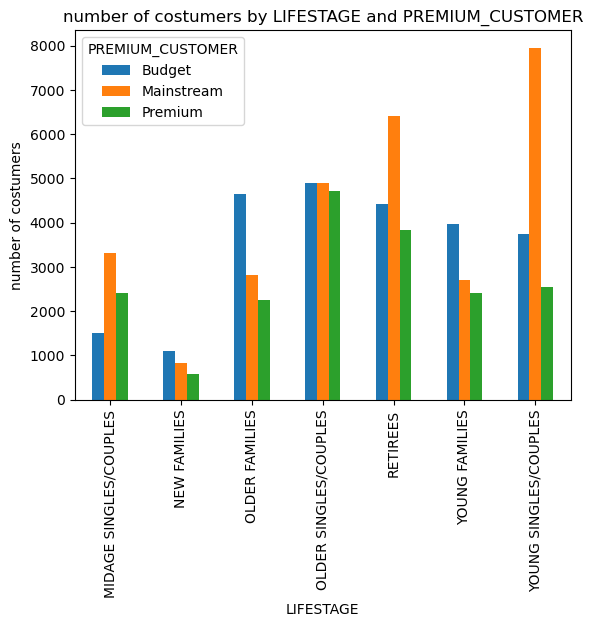

In [37]:
ncos=data.groupby(segments)["LYLTY_CARD_NBR"].nunique().reset_index(name="number_costumers")
ncos_pivot=ncos.pivot(index="LIFESTAGE",columns="PREMIUM_CUSTOMER",values="number_costumers")
plt.figure()
ncos_pivot.plot(kind="bar")
plt.title("number of costumers by LIFESTAGE and PREMIUM_CUSTOMER")
plt.xlabel("LIFESTAGE")
plt.ylabel("number of costumers")
plt.xticks(rotation=90)
plt.show()

In [39]:
unit_by_seg=data.groupby(segments).agg(total_unit=("PROD_QTY","sum"),total_cos=("LYLTY_CARD_NBR","nunique")).reset_index()
unit_by_seg["average_buy"]=unit_by_seg["total_unit"]/unit_by_seg["total_cos"] 
unit_by_seg.sort_values("average_buy",ascending=False).head(40)

,LIFESTAGE,PREMIUM_CUSTOMER,total_unit,total_cos,average_buy
7,OLDER FAMILIES,Mainstream,26833,2808,9.555912
6,OLDER FAMILIES,Budget,43581,4641,9.390433
8,OLDER FAMILIES,Premium,21079,2252,9.360124
15,YOUNG FAMILIES,Budget,35810,3980,8.997487
16,YOUNG FAMILIES,Mainstream,24238,2702,8.970392
17,YOUNG FAMILIES,Premium,21674,2422,8.948803
11,OLDER SINGLES/COUPLES,Premium,32729,4715,6.941463
9,OLDER SINGLES/COUPLES,Budget,33930,4892,6.935814
10,OLDER SINGLES/COUPLES,Mainstream,33820,4894,6.910503
1,MIDAGE SINGLES/COUPLES,Mainstream,21743,3308,6.572854


In [41]:
units_by_seg=data.groupby(segments).agg(total_sales=("TOT_SALES","sum"),total_cos=("LYLTY_CARD_NBR","nunique")).reset_index()
units_by_seg["average_buy"]=units_by_seg["total_sales"]/units_by_seg["total_cos"] 
units_by_seg.sort_values("average_buy",ascending=False).head(40)

,LIFESTAGE,PREMIUM_CUSTOMER,total_sales,total_cos,average_buy
7,OLDER FAMILIES,Mainstream,98738.25,2808,35.163194
6,OLDER FAMILIES,Budget,160794.85,4641,34.646596
8,OLDER FAMILIES,Premium,77129.20,2252,34.249201
15,YOUNG FAMILIES,Budget,132710.75,3980,33.344410
17,YOUNG FAMILIES,Premium,80292.30,2422,33.151239
16,YOUNG FAMILIES,Mainstream,88678.15,2702,32.819449
11,OLDER SINGLES/COUPLES,Premium,125852.45,4715,26.691930
9,OLDER SINGLES/COUPLES,Budget,130190.80,4892,26.613001
10,OLDER SINGLES/COUPLES,Mainstream,127391.10,4894,26.030057
1,MIDAGE SINGLES/COUPLES,Mainstream,85928.25,3308,25.975892


In [43]:
target_lifestages = ["YOUNG SINGLES/COUPLES", "MIDAGE SINGLES/COUPLES"]
sub = data.loc[data["LIFESTAGE"].isin(target_lifestages)].copy()

def welch_ttest(group_a, group_b):
    a = group_a.dropna().values
    b = group_b.dropna().values
    res = stats.ttest_ind(a, b, equal_var=False)  # Welch t-test
    return float(res.statistic), float(res.pvalue), len(a), len(b)

results = []
for ls in target_lifestages:
    for other in ["Budget", "Premium"]:
        a = sub.loc[(sub["LIFESTAGE"] == ls) & (sub["PREMIUM_CUSTOMER"] == "Mainstream"), "unit_price"]
        b = sub.loc[(sub["LIFESTAGE"] == ls) & (sub["PREMIUM_CUSTOMER"] == other), "unit_price"]
        t, p, na, nb = welch_ttest(a, b)
        results.append({
            "LIFESTAGE": ls,
            "COMPARE": f"MAINSTREAM vs {other}",
            "t": t,
            "p_value": p,
            "n_mainstream": na,
            "n_other": nb
        })

ttest_df = pd.DataFrame(results)
ttest_df


,LIFESTAGE,COMPARE,t,p_value,n_mainstream,n_other
0,YOUNG SINGLES/COUPLES,MAINSTREAM vs Budget,31.323718,4.547113e-209,19987,8963
1,YOUNG SINGLES/COUPLES,MAINSTREAM vs Premium,26.178115,7.647497e-146,19987,6103
2,MIDAGE SINGLES/COUPLES,MAINSTREAM vs Budget,14.111097,9.889784e-45,11373,4876
3,MIDAGE SINGLES/COUPLES,MAINSTREAM vs Premium,15.301979,1.702986e-52,11373,7946


In [47]:
target = data.loc[(data["LIFESTAGE"] == "YOUNG SINGLES/COUPLES") & (data["PREMIUM_CUSTOMER"] == "Mainstream")].copy()
other  = data.loc[~((data["LIFESTAGE"] == "YOUNG SINGLES/COUPLES") & (data["PREMIUM_CUSTOMER"] == "Mainstream"))].copy()

def affinity_table(col, target_df, other_df):
    target_share = target_df[col].value_counts(normalize=True)
    other_share  = other_df[col].value_counts(normalize=True)

    out = pd.concat([target_share.rename("share_target"),
                     other_share.rename("share_other")], axis=1).fillna(0)

    out["affinity"] = np.where(out["share_other"] > 0, out["share_target"] / out["share_other"], np.nan)
    out = out.sort_values("affinity", ascending=False).reset_index().rename(columns={"index": col})
    return out


In [49]:
brand_aff = affinity_table("brand", target, other)
brand_aff.head(20)


,brand,share_target,share_other,affinity
0,TYRRELLS,0.030970,0.024724,1.252650
1,TWISTIES,0.045029,0.036319,1.239821
2,TOSTITOS,0.044529,0.036434,1.222187
3,KETTLE,0.192325,0.158982,1.209726
4,PRINGLES,0.115825,0.096751,1.197153
5,GRAIN,0.028819,0.024184,1.191621
6,DORITOS,0.127133,0.108711,1.169452
7,COBS,0.043228,0.037487,1.153156
8,INFUZIONS,0.062541,0.054988,1.137346
9,THINS,0.058338,0.054810,1.064368


In [51]:
pack_aff = affinity_table("pack_size", target, other)
pack_aff.head(20)


,pack_size,share_target,share_other,affinity
0,270.0,0.031020,0.024053,1.289667
1,380.0,0.031320,0.024584,1.274035
2,330.0,0.059789,0.048169,1.241221
3,134.0,0.115825,0.096751,1.197153
4,210.0,0.028819,0.024184,1.191621
5,110.0,0.102617,0.086344,1.188463
6,135.0,0.014509,0.012597,1.151771
7,250.0,0.014009,0.012266,1.142079
8,170.0,0.078801,0.078158,1.008230
9,175.0,0.250013,0.260667,0.959127


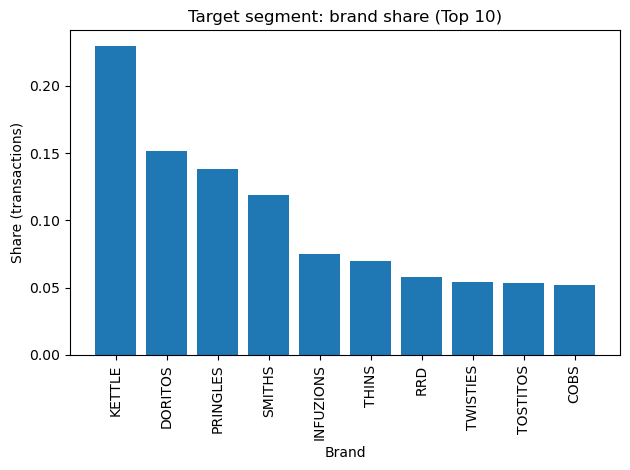

In [53]:
top_brands = target["brand"].value_counts().head(10)
plt.figure()
plt.bar(top_brands.index, (top_brands / top_brands.sum()).values)
plt.title("Target segment: brand share (Top 10)")
plt.xlabel("Brand")
plt.ylabel("Share (transactions)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


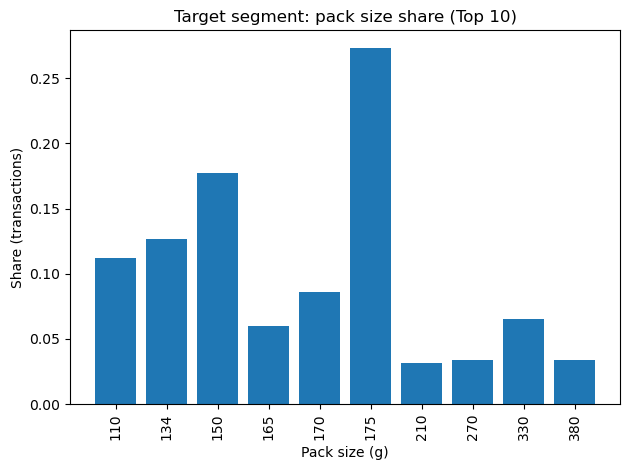

In [55]:
top_packs = target["pack_size"].value_counts().head(10)
top_packs_share = (top_packs / top_packs.sum()).sort_index()

plt.figure()
plt.bar(top_packs_share.index.astype(int).astype(str), top_packs_share.values)
plt.title("Target segment: pack size share (Top 10)")
plt.xlabel("Pack size (g)")
plt.ylabel("Share (transactions)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [57]:

path = "D:\quantium chips\QVI_data.csv"
df = pd.read_csv(path)

df.head()


<>:1: SyntaxWarning: invalid escape sequence '\q'
<>:1: SyntaxWarning: invalid escape sequence '\q'
C:\Users\jueyo\AppData\Local\Temp\ipykernel_26444\3846179827.py:1: SyntaxWarning: invalid escape sequence '\q'
  path = "D:\quantium chips\QVI_data.csv"


,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream


In [59]:
# 如果 DATE 是 Excel serial（四万多那种），用 origin 解析；
# 如果 DATE 是正常日期字符串，pd.to_datetime 也能解析。
if np.issubdtype(df["DATE"].dtype, np.number):
    dt = pd.to_datetime(df["DATE"], unit="D", origin="1899-12-30", errors="coerce")
else:
    dt = pd.to_datetime(df["DATE"], errors="coerce")

df["YEARMONTH"] = dt.dt.year * 100 + dt.dt.month   # e.g. 201901
df["DATE_PARSED"] = dt

df[["DATE", "DATE_PARSED", "YEARMONTH"]].head()


,DATE,DATE_PARSED,YEARMONTH
0,2018-10-17,2018-10-17,201810
1,2018-09-16,2018-09-16,201809
2,2019-03-07,2019-03-07,201903
3,2019-03-08,2019-03-08,201903
4,2018-11-02,2018-11-02,201811


In [61]:

STORE_COL = "STORE_NBR"
CUST_COL  = "LYLTY_CARD_NBR"
TXN_COL   = "TXN_ID"
SALES_COL = "TOT_SALES"
QTY_COL   = "PROD_QTY"

monthly = (
    df.groupby([STORE_COL, "YEARMONTH"], as_index=False)
      .agg(
          totSales=(SALES_COL, "sum"),
          nCustomers=(CUST_COL, "nunique"),
          nTxns=(TXN_COL, "nunique"),
          chipsQty=(QTY_COL, "sum"),
      )
      .sort_values([STORE_COL, "YEARMONTH"])
      .reset_index(drop=True)
)

# 题目要求的第3个指标：每个顾客平均交易次数
monthly["nTxnPerCust"] = monthly["nTxns"] / monthly["nCustomers"].replace(0, np.nan)

# 两个辅助指标（可选）
monthly["nChipsPerTxn"] = monthly["chipsQty"] / monthly["nTxns"].replace(0, np.nan)
monthly["avgPricePerUnit"] = monthly["totSales"] / monthly["chipsQty"].replace(0, np.nan)

monthly.head()


,STORE_NBR,YEARMONTH,totSales,nCustomers,nTxns,chipsQty,nTxnPerCust,nChipsPerTxn,avgPricePerUnit
0,1,201807,206.9,49,52,62,1.061224,1.192308,3.337097
1,1,201808,176.1,42,43,54,1.023810,1.255814,3.261111
2,1,201809,278.8,59,62,75,1.050847,1.209677,3.717333
3,1,201810,188.1,44,45,58,1.022727,1.288889,3.243103
4,1,201811,192.6,46,47,57,1.021739,1.212766,3.378947


In [63]:
TRIAL_STORES = [77, 86, 88]     # 试点门店列表

PRETRIAL_END = 201902           # pre-trial 截止到 201902 之前（不含201902）
TRIAL_START  = 201902           # 试点开始月（含）
TRIAL_END    = 201904           # 试点结束月（含）

pretrial = monthly[monthly["YEARMONTH"] < PRETRIAL_END].copy()
# 取出 pre-trial 的月度数据（用于选control、算缩放系数）

trial_period = monthly[(monthly["YEARMONTH"] >= TRIAL_START) & (monthly["YEARMONTH"] <= TRIAL_END)].copy()
# 取出试点期间（Feb–Apr 2019）的月度数据（用于评估效果）

pretrial["YEARMONTH"].unique()[:10], pretrial["YEARMONTH"].nunique()
# 简单检查：pre-trial 有哪些月份、总共有多少个月


(array([201807, 201808, 201809, 201810, 201811, 201812, 201901]), 7)

In [65]:
months_per_store = pretrial.groupby(STORE_COL)["YEARMONTH"].nunique()
# 对每个门店统计：在 pre-trial 期间有多少个月的数据（去重计数）

expected_months = pretrial["YEARMONTH"].nunique()
# pre-trial 总共有多少个月（作为“完整”的标准）

candidate_stores = months_per_store[months_per_store == expected_months].index.tolist()
# 只保留那些月份数=expected_months 的门店（即每个月都有数据），作为候选 control

len(candidate_stores), expected_months
# 输出：候选门店数量、以及预期月份数，确认筛选结果


(260, 7)

In [67]:
trial_store = 77
# 当前要为哪一家 trial 店找 control（先用 77 演示）

pre = pretrial[pretrial[STORE_COL].isin(candidate_stores)].copy()
# 只保留 pre-trial 且在候选门店列表里的数据（保证比较公平）

pivot_sales = pre.pivot(index="YEARMONTH", columns=STORE_COL, values="totSales").sort_index()
# 做透视表：行=月份，列=门店，值=totSales（后面用来算相关/距离）

trial_sales_series = pivot_sales[trial_store]
# 取出 trial 店（77）的销售序列（按月）

corr_sales = []
# 准备一个列表存每个候选门店与 trial 的销售相关系数

for s in pivot_sales.columns:
    # 遍历所有门店（列）
    if s == trial_store:
        continue
    # 跳过自己（trial 不和自己比）
    corr_sales.append((int(s), trial_sales_series.corr(pivot_sales[s])))
    # 计算 trial vs 候选门店 的 Pearson 相关系数，并保存

corr_sales = pd.DataFrame(corr_sales, columns=["Store2", "corr_sales"])
# 把列表转成 DataFrame：Store2=候选门店，corr_sales=相关性得分

diff_sales = (pivot_sales.sub(trial_sales_series, axis=0)).abs().drop(columns=[trial_store], errors="ignore")
# 计算“每月 |候选 - trial|”的绝对差；drop掉 trial 自己那列

min_dist = diff_sales.min(axis=1)
# 每个月：所有候选门店中最小的差值（用于标准化）

max_dist = diff_sales.max(axis=1)
# 每个月：所有候选门店中最大的差值（用于标准化）

denom = (max_dist - min_dist).replace(0, np.nan)
# 标准化的分母；如果 max=min（分母0），先变成NaN避免除0

mag_sales = 1 - (diff_sales.sub(min_dist, axis=0)).div(denom, axis=0)
# 标准化幅度相似度：1 - (diff - min)/(max - min)；越接近1越像

mag_sales = mag_sales.fillna(1.0)
# 如果分母为0（大家一样远），就都记为 1（该月无法区分，视作同样相似）

mag_sales_score = mag_sales.mean(axis=0).reset_index()
# 对每个候选门店，把“每月的相似度”取平均，得到一个总体相似度

mag_sales_score.columns = ["Store2", "mag_sales"]
# 重命名列：Store2=候选门店，mag_sales=幅度相似度

pivot_cust = pre.pivot(index="YEARMONTH", columns=STORE_COL, values="nCustomers").sort_index()
# 对顾客数也做同样透视表（行=月份，列=门店，值=顾客数）

trial_cust_series = pivot_cust[trial_store]
# 取出 trial 店的顾客数序列

corr_cust = []
# 存相关性（顾客数）

for s in pivot_cust.columns:
    if s == trial_store:
        continue
    corr_cust.append((int(s), trial_cust_series.corr(pivot_cust[s])))
# trial 顾客数 vs 候选顾客数 的 Pearson 相关系数

corr_cust = pd.DataFrame(corr_cust, columns=["Store2", "corr_cust"])
# 转成 DataFrame

diff_cust = (pivot_cust.sub(trial_cust_series, axis=0)).abs().drop(columns=[trial_store], errors="ignore")
# 顾客数的绝对差（每月）

min_dist = diff_cust.min(axis=1)
max_dist = diff_cust.max(axis=1)
denom = (max_dist - min_dist).replace(0, np.nan)
# 同样做标准化准备

mag_cust = 1 - (diff_cust.sub(min_dist, axis=0)).div(denom, axis=0)
mag_cust = mag_cust.fillna(1.0)
# 顾客数的幅度相似度（越接近1越像）

mag_cust_score = mag_cust.mean(axis=0).reset_index()
mag_cust_score.columns = ["Store2", "mag_cust"]
# 顾客数幅度相似度（按候选门店平均）

score_sales = corr_sales.merge(mag_sales_score, on="Store2")
# 把销售的 corr + mag 合并到同一张表（按候选门店 Store2 对齐）

score_cust = corr_cust.merge(mag_cust_score, on="Store2")
# 把顾客数的 corr + mag 合并

corr_weight = 0.5
# 权重：0.5 表示相关性和幅度距离各占一半（可调）

score = (
    score_sales.merge(score_cust, on="Store2")
              .assign(
                  score_sales=lambda x: corr_weight*x["corr_sales"] + (1-corr_weight)*x["mag_sales"],
                  score_cust =lambda x: corr_weight*x["corr_cust"]  + (1-corr_weight)*x["mag_cust"],
              )
)
# 合并 sales 和 customers 两张表；
# 然后计算两个综合得分：sales综合分、cust综合分

score["finalControlScore"] = 0.5*score["score_sales"] + 0.5*score["score_cust"]
# 最终总分：销售综合分与顾客综合分再平均

score = score.sort_values("finalControlScore", ascending=False).reset_index(drop=True)
# 按最终总分从高到低排序，第一名就是最匹配的 control

score.head(10)
# 看前10名候选control及其得分


,Store2,corr_sales,mag_sales,corr_cust,mag_cust,score_sales,score_cust,finalControlScore
0,233,0.903774,0.987091,0.990358,0.992773,0.945433,0.991566,0.968499
1,41,0.783232,0.966917,0.844219,0.974639,0.875075,0.909429,0.892252
2,17,0.842668,0.882314,0.747308,0.962495,0.862491,0.854902,0.858696
3,254,0.577108,0.924468,0.916208,0.937131,0.750788,0.926670,0.838729
4,115,0.689159,0.934576,0.718882,0.965916,0.811868,0.842399,0.827133
5,84,0.684348,0.831604,0.858571,0.924182,0.757976,0.891377,0.824676
6,167,0.657110,0.960916,0.717913,0.949349,0.809013,0.833631,0.821322
7,50,0.763866,0.974929,0.607391,0.925076,0.869398,0.766234,0.817816
8,111,0.519473,0.967254,0.685926,0.966064,0.743364,0.825995,0.784679
9,265,0.639759,0.964439,0.573460,0.947902,0.802099,0.760681,0.781390


In [69]:
control_store = int(score.iloc[0]["Store2"])
# 取最终得分最高的候选门店作为 control

control_store
# 输出 control 门店编号


233

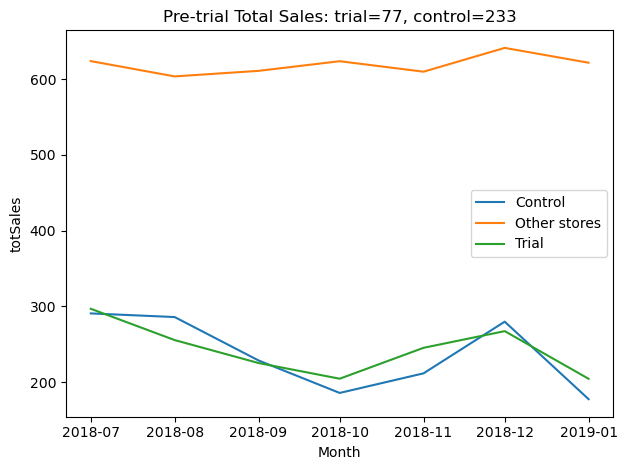

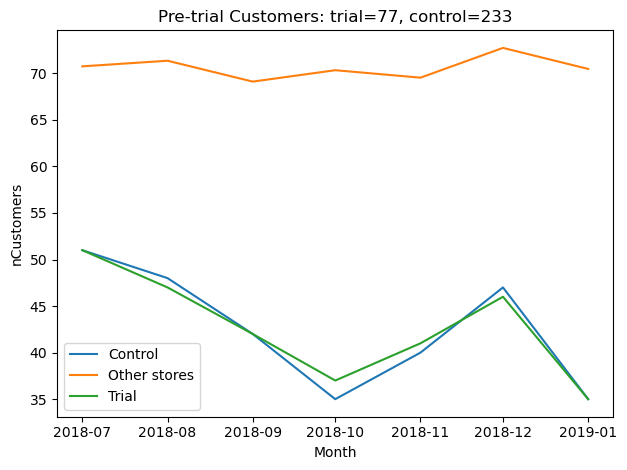

In [71]:
tmp = monthly.copy()
# 复制一份月度数据，避免改动原表

tmp["Store_type"] = np.where(
    tmp[STORE_COL] == trial_store, "Trial",
    np.where(tmp[STORE_COL] == control_store, "Control", "Other stores")
)
# 给每条记录打标签：Trial / Control / Other（其他门店）

tmp2 = tmp[tmp["YEARMONTH"] < PRETRIAL_END].copy()
# 只保留 pre-trial 时段，用于“选control的合理性”可视化检查

tmp2["Month"] = pd.to_datetime(tmp2["YEARMONTH"].astype(str) + "01", format="%Y%m%d")
# 把 yyyymm 转成日期（用每月1号表示），便于画时间序列

plot_df = tmp2.groupby(["Month","Store_type"], as_index=False)[["totSales","nCustomers"]].mean()
# 按 月份 + Store_type 聚合取平均：
# Trial 只有一家所以等于它本身；
# Other stores 是很多家，平均后是一条“其他店平均线”

plt.figure()
# 新建一张图

for k, sub in plot_df.groupby("Store_type"):
    plt.plot(sub["Month"], sub["totSales"], label=k)
# 按 Store_type 分组画三条线：Trial、Control、Other

plt.title(f"Pre-trial Total Sales: trial={trial_store}, control={control_store}")
plt.xlabel("Month"); plt.ylabel("totSales")
plt.legend(); plt.tight_layout()
plt.show()
# 这一段是销售额的 pre-trial 趋势图

plt.figure()
for k, sub in plot_df.groupby("Store_type"):
    plt.plot(sub["Month"], sub["nCustomers"], label=k)
# 这一段画顾客数的 pre-trial 趋势图

plt.title(f"Pre-trial Customers: trial={trial_store}, control={control_store}")
plt.xlabel("Month"); plt.ylabel("nCustomers")
plt.legend(); plt.tight_layout()
plt.show()


In [73]:
metric = "totSales"
# 选择要评估的指标（先评估销售额）

trial_sum = monthly.loc[(monthly[STORE_COL]==trial_store) & (monthly["YEARMONTH"] < PRETRIAL_END), metric].sum()
# trial 店在 pre-trial 期间的该指标总和（作为基准）

ctrl_sum  = monthly.loc[(monthly[STORE_COL]==control_store) & (monthly["YEARMONTH"] < PRETRIAL_END), metric].sum()
# control 店在 pre-trial 期间的该指标总和

scaling = trial_sum / ctrl_sum
# 缩放因子：让 control_scaled ≈ trial（在 pre-trial 总体水平一致）

scaling
# 输出 scaling


1.023617303289553

In [75]:
trial_series = monthly.loc[monthly[STORE_COL]==trial_store, ["YEARMONTH", metric]].rename(columns={metric:"trial"})
# 取 trial 店每月的 metric，并把列名改为 trial

ctrl_series  = monthly.loc[monthly[STORE_COL]==control_store, ["YEARMONTH", metric]].rename(columns={metric:"control"})
# 取 control 店每月的 metric，并把列名改为 control

comp = trial_series.merge(ctrl_series, on="YEARMONTH", how="inner").sort_values("YEARMONTH")
# 按月份把 trial 和 control 合并成一张表（只保留两者都有的月份）

comp["control_scaled"] = comp["control"] * scaling
# 把 control 按 scaling 缩放，得到可比的 control_scaled

comp["percentageDiff"] = (comp["control_scaled"] - comp["trial"]).abs() / comp["control_scaled"].replace(0, np.nan)
# 计算绝对百分比差：|control_scaled - trial| / control_scaled
# replace(0, NaN) 避免分母为0

comp.head()
# 看前几行确认计算结果


,YEARMONTH,trial,control,control_scaled,percentageDiff
0,201807,296.8,290.7,297.565550,0.002573
1,201808,255.5,285.9,292.652187,0.126950
2,201809,225.2,228.6,233.998916,0.037602
3,201810,204.5,185.7,190.085733,0.075830
4,201811,245.3,211.6,216.597421,0.132516


In [77]:
pre_mask = comp["YEARMONTH"] < PRETRIAL_END
# 标记哪些行属于 pre-trial（月）

std_dev = comp.loc[pre_mask, "percentageDiff"].std(ddof=1)
# pre-trial 的 percentageDiff 标准差（样本标准差 ddof=1）
# 用它表示“正常波动大小”

n_pre = pre_mask.sum()
# pre-trial 一共有多少个月（样本量）

t_95 = stats.t.ppf(0.95, df=max(n_pre-1, 1))
# t 分布 95% 分位数（右尾），自由度=月数-1（更通用，不写死7）

std_dev, n_pre, t_95
# 输出这三个值，方便检查


(0.04994076264142537, 7, 1.9431802805153022)

In [79]:
trial_mask = (comp["YEARMONTH"] >= TRIAL_START) & (comp["YEARMONTH"] <= TRIAL_END)
# 标记试点期（月）

trial_check = comp.loc[trial_mask, ["YEARMONTH","percentageDiff"]].copy()
# 取出试点期的百分比差

trial_check["tValue"] = trial_check["percentageDiff"] / (std_dev if std_dev!=0 else np.nan)
# tValue = percentageDiff / std_dev（用“波动标准差”做标准化）
# 如果 std_dev=0，则设为 NaN 避免除0

trial_check["Significant(>t95)"] = trial_check["tValue"] > t_95
# 如果 tValue > t_95，就标记为“显著超出正常波动”

trial_check
# 输出试点期三个月的结果表


,YEARMONTH,percentageDiff,tValue,Significant(>t95)
7,201902,0.059107,1.183534,False
8,201903,0.366521,7.339116,True
9,201904,0.623080,12.476373,True


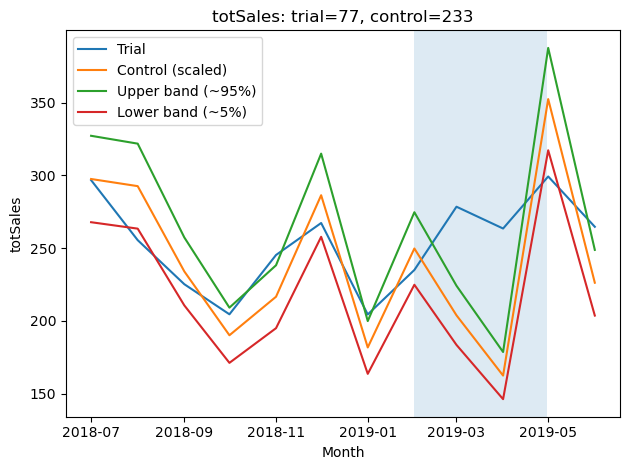

In [81]:
comp["Month"] = pd.to_datetime(comp["YEARMONTH"].astype(str) + "01", format="%Y%m%d")
# 把 yyyymm 转成每月1号日期，方便画折线图

upper = comp["control_scaled"] * (1 + 2*std_dev)
lower = comp["control_scaled"] * (1 - 2*std_dev)
# 用 ±2*std_dev 构造一条“近似置信带”（模板风格，便于可视化）

plt.figure()
plt.plot(comp["Month"], comp["trial"], label="Trial")
# 画 trial 真实值

plt.plot(comp["Month"], comp["control_scaled"], label="Control (scaled)")
# 画缩放后的 control 作为对照基线

plt.plot(comp["Month"], upper, label="Upper band (~95%)")
plt.plot(comp["Month"], lower, label="Lower band (~5%)")
# 画上下界（可视化“正常范围”）

start = pd.to_datetime(str(TRIAL_START) + "01", format="%Y%m%d")
end   = pd.to_datetime(str(TRIAL_END)   + "01", format="%Y%m%d") + pd.offsets.MonthEnd(0)
# 把试点开始月、结束月转成日期范围（end 加到月末）

plt.axvspan(start, end, alpha=0.15)
# 用浅色区域标出试点期间（Feb–Apr）

plt.title(f"{metric}: trial={trial_store}, control={control_store}")
plt.xlabel("Month"); plt.ylabel(metric)
plt.legend(); plt.tight_layout()
plt.show()
# 输出图：看 trial 是否明显偏离 control_scaled 的置信带


In [83]:
metric = "nCustomers"

trial_sum = monthly.loc[(monthly[STORE_COL]==trial_store) & (monthly["YEARMONTH"] < PRETRIAL_END), metric].sum()
ctrl_sum  = monthly.loc[(monthly[STORE_COL]==control_store) & (monthly["YEARMONTH"] < PRETRIAL_END), metric].sum()
scaling = trial_sum / ctrl_sum

trial_series = monthly.loc[monthly[STORE_COL]==trial_store, ["YEARMONTH", metric]].rename(columns={metric:"trial"})
ctrl_series  = monthly.loc[monthly[STORE_COL]==control_store, ["YEARMONTH", metric]].rename(columns={metric:"control"})

comp = trial_series.merge(ctrl_series, on="YEARMONTH", how="inner").sort_values("YEARMONTH")
comp["control_scaled"] = comp["control"] * scaling
comp["percentageDiff"] = (comp["control_scaled"] - comp["trial"]).abs() / comp["control_scaled"].replace(0, np.nan)

pre_mask = comp["YEARMONTH"] < PRETRIAL_END
std_dev = comp.loc[pre_mask, "percentageDiff"].std(ddof=1)
n_pre = pre_mask.sum()
t_95 = stats.t.ppf(0.95, df=max(n_pre-1, 1))

trial_mask = (comp["YEARMONTH"] >= TRIAL_START) & (comp["YEARMONTH"] <= TRIAL_END)
trial_check = comp.loc[trial_mask, ["YEARMONTH","percentageDiff"]].copy()
trial_check["tValue"] = trial_check["percentageDiff"] / (std_dev if std_dev!=0 else np.nan)
trial_check["Significant(>t95)"] = trial_check["tValue"] > t_95

trial_check


,YEARMONTH,percentageDiff,tValue,Significant(>t95)
7,201902,0.003344,0.183352,False
8,201903,0.245819,13.476388,True
9,201904,0.561427,30.778725,True


In [85]:
results = []

for trial_store in [77, 86, 88]:
    pre = pretrial[pretrial[STORE_COL].isin(candidate_stores)].copy()

    # --- 选 control（同 Cell 7/8 的逻辑）---
    pivot_sales = pre.pivot(index="YEARMONTH", columns=STORE_COL, values="totSales").sort_index()
    trial_sales_series = pivot_sales[trial_store]

    corr_sales = []
    for s in pivot_sales.columns:
        if s == trial_store:
            continue
        corr_sales.append((int(s), trial_sales_series.corr(pivot_sales[s])))
    corr_sales = pd.DataFrame(corr_sales, columns=["Store2", "corr_sales"])

    diff_sales = (pivot_sales.sub(trial_sales_series, axis=0)).abs().drop(columns=[trial_store], errors="ignore")
    min_dist = diff_sales.min(axis=1)
    max_dist = diff_sales.max(axis=1)
    denom = (max_dist - min_dist).replace(0, np.nan)
    mag_sales = 1 - (diff_sales.sub(min_dist, axis=0)).div(denom, axis=0)
    mag_sales = mag_sales.fillna(1.0)
    mag_sales_score = mag_sales.mean(axis=0).reset_index()
    mag_sales_score.columns = ["Store2", "mag_sales"]

    pivot_cust = pre.pivot(index="YEARMONTH", columns=STORE_COL, values="nCustomers").sort_index()
    trial_cust_series = pivot_cust[trial_store]

    corr_cust = []
    for s in pivot_cust.columns:
        if s == trial_store:
            continue
        corr_cust.append((int(s), trial_cust_series.corr(pivot_cust[s])))
    corr_cust = pd.DataFrame(corr_cust, columns=["Store2", "corr_cust"])

    diff_cust = (pivot_cust.sub(trial_cust_series, axis=0)).abs().drop(columns=[trial_store], errors="ignore")
    min_dist = diff_cust.min(axis=1)
    max_dist = diff_cust.max(axis=1)
    denom = (max_dist - min_dist).replace(0, np.nan)
    mag_cust = 1 - (diff_cust.sub(min_dist, axis=0)).div(denom, axis=0)
    mag_cust = mag_cust.fillna(1.0)
    mag_cust_score = mag_cust.mean(axis=0).reset_index()
    mag_cust_score.columns = ["Store2", "mag_cust"]

    corr_weight = 0.5
    score = (corr_sales.merge(mag_sales_score, on="Store2")
                    .merge(corr_cust.merge(mag_cust_score, on="Store2"), on="Store2"))
    score["score_sales"] = corr_weight*score["corr_sales"] + (1-corr_weight)*score["mag_sales"]
    score["score_cust"]  = corr_weight*score["corr_cust"]  + (1-corr_weight)*score["mag_cust"]
    score["finalControlScore"] = 0.5*score["score_sales"] + 0.5*score["score_cust"]
    score = score.sort_values("finalControlScore", ascending=False).reset_index(drop=True)

    control_store = int(score.iloc[0]["Store2"])

    results.append({"trial_store": trial_store, "control_store": control_store})

pd.DataFrame(results)


,trial_store,control_store
0,77,233
1,86,155
2,88,237


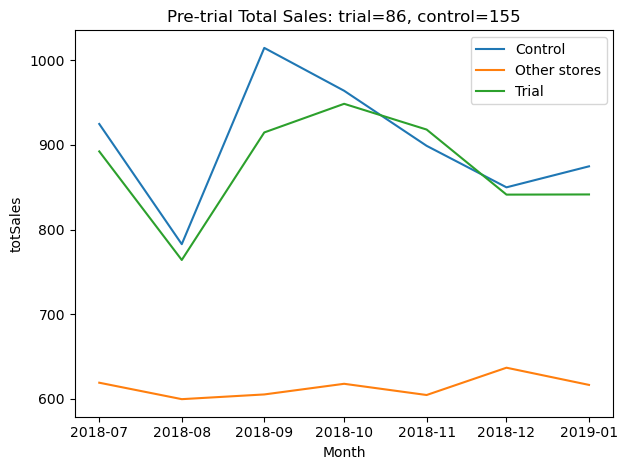

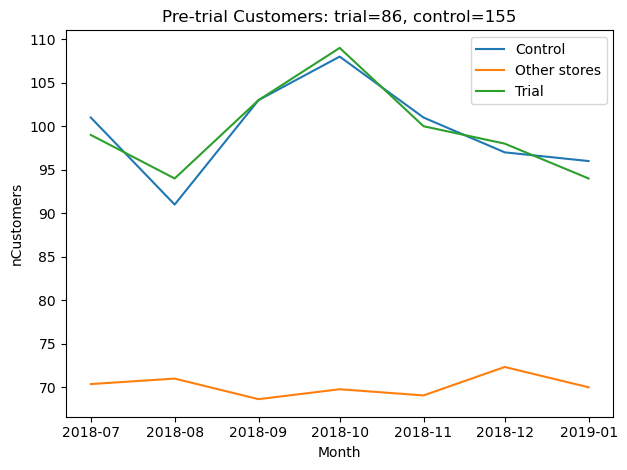

In [87]:
trial_store = 86
control_store=155
tmp = monthly.copy()
# 复制一份月度数据，避免改动原表

tmp["Store_type"] = np.where(
    tmp[STORE_COL] == trial_store, "Trial",
    np.where(tmp[STORE_COL] == control_store, "Control", "Other stores")
)
# 给每条记录打标签：Trial / Control / Other（其他门店）

tmp2 = tmp[tmp["YEARMONTH"] < PRETRIAL_END].copy()
# 只保留 pre-trial 时段，用于“选control的合理性”可视化检查

tmp2["Month"] = pd.to_datetime(tmp2["YEARMONTH"].astype(str) + "01", format="%Y%m%d")
# 把 yyyymm 转成日期（用每月1号表示），便于画时间序列

plot_df = tmp2.groupby(["Month","Store_type"], as_index=False)[["totSales","nCustomers"]].mean()
# 按 月份 + Store_type 聚合取平均：
# Trial 只有一家所以等于它本身；
# Other stores 是很多家，平均后是一条“其他店平均线”

plt.figure()
# 新建一张图

for k, sub in plot_df.groupby("Store_type"):
    plt.plot(sub["Month"], sub["totSales"], label=k)
# 按 Store_type 分组画三条线：Trial、Control、Other

plt.title(f"Pre-trial Total Sales: trial={trial_store}, control={control_store}")
plt.xlabel("Month"); plt.ylabel("totSales")
plt.legend(); plt.tight_layout()
plt.show()
# 这一段是销售额的 pre-trial 趋势图

plt.figure()
for k, sub in plot_df.groupby("Store_type"):
    plt.plot(sub["Month"], sub["nCustomers"], label=k)
# 这一段画顾客数的 pre-trial 趋势图

plt.title(f"Pre-trial Customers: trial={trial_store}, control={control_store}")
plt.xlabel("Month"); plt.ylabel("nCustomers")
plt.legend(); plt.tight_layout()
plt.show()


In [89]:
metric = "totSales"
# 选择要评估的指标（先评估销售额）

trial_sum = monthly.loc[(monthly[STORE_COL]==trial_store) & (monthly["YEARMONTH"] < PRETRIAL_END), metric].sum()
# trial 店在 pre-trial 期间的该指标总和（作为基准）

ctrl_sum  = monthly.loc[(monthly[STORE_COL]==control_store) & (monthly["YEARMONTH"] < PRETRIAL_END), metric].sum()
# control 店在 pre-trial 期间的该指标总和

scaling = trial_sum / ctrl_sum
# 缩放因子：让 control_scaled ≈ trial（在 pre-trial 总体水平一致）

scaling
# 输出 scaling


0.9700651481287743

In [91]:
trial_series = monthly.loc[monthly[STORE_COL]==trial_store, ["YEARMONTH", metric]].rename(columns={metric:"trial"})
# 取 trial 店每月的 metric，并把列名改为 trial

ctrl_series  = monthly.loc[monthly[STORE_COL]==control_store, ["YEARMONTH", metric]].rename(columns={metric:"control"})
# 取 control 店每月的 metric，并把列名改为 control

comp = trial_series.merge(ctrl_series, on="YEARMONTH", how="inner").sort_values("YEARMONTH")
# 按月份把 trial 和 control 合并成一张表（只保留两者都有的月份）

comp["control_scaled"] = comp["control"] * scaling
# 把 control 按 scaling 缩放，得到可比的 control_scaled

comp["percentageDiff"] = (comp["control_scaled"] - comp["trial"]).abs() / comp["control_scaled"].replace(0, np.nan)
# 计算绝对百分比差：|control_scaled - trial| / control_scaled
# replace(0, NaN) 避免分母为0

comp.head()
# 看前几行确认计算结果


,YEARMONTH,trial,control,control_scaled,percentageDiff
0,201807,892.20,924.6,896.922236,0.005265
1,201808,764.05,782.7,759.269991,0.006296
2,201809,914.60,1014.4,984.034086,0.070561
3,201810,948.40,963.8,934.948790,0.014387
4,201811,918.00,898.8,871.894555,0.052880


In [97]:
pre_mask = comp["YEARMONTH"] < PRETRIAL_END
# 标记哪些行属于 pre-trial（月）

std_dev = comp.loc[pre_mask, "percentageDiff"].std(ddof=1)
# pre-trial 的 percentageDiff 标准差（样本标准差 ddof=1）
# 用它表示“正常波动大小”

n_pre = pre_mask.sum()
# pre-trial 一共有多少个月（样本量）

t_95 = stats.t.ppf(0.95, df=max(n_pre-1, 1))
# t 分布 95% 分位数（右尾），自由度=月数-1（更通用，不写死7）

std_dev, n_pre, t_95
# 输出这三个值，方便检查
trial_mask = (comp["YEARMONTH"] >= TRIAL_START) & (comp["YEARMONTH"] <= TRIAL_END)
# 标记试点期（月）

trial_check = comp.loc[trial_mask, ["YEARMONTH","percentageDiff"]].copy()
# 取出试点期的百分比差

trial_check["tValue"] = trial_check["percentageDiff"] / (std_dev if std_dev!=0 else np.nan)
# tValue = percentageDiff / std_dev（用“波动标准差”做标准化）
# 如果 std_dev=0，则设为 NaN 避免除0

trial_check["Significant(>t95)"] = trial_check["tValue"] > t_95
# 如果 tValue > t_95，就标记为“显著超出正常波动”

trial_check




,YEARMONTH,percentageDiff,tValue,Significant(>t95)
7,201902,0.056306,2.179542,True
8,201903,0.315870,12.226922,True
9,201904,0.035253,1.364580,False


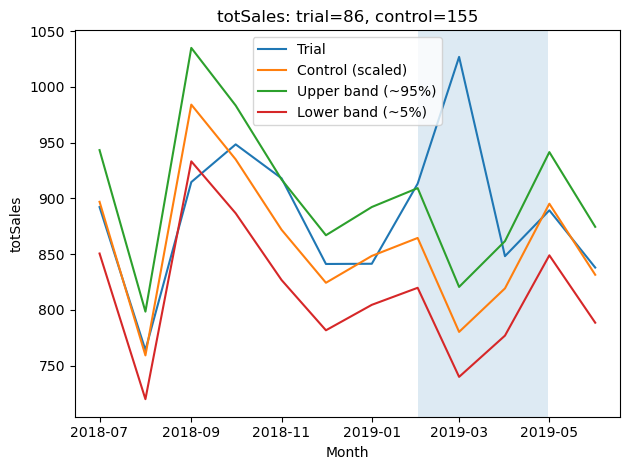

In [99]:
comp["Month"] = pd.to_datetime(comp["YEARMONTH"].astype(str) + "01", format="%Y%m%d")
# 把 yyyymm 转成每月1号日期，方便画折线图

upper = comp["control_scaled"] * (1 + 2*std_dev)
lower = comp["control_scaled"] * (1 - 2*std_dev)
# 用 ±2*std_dev 构造一条“近似置信带”（模板风格，便于可视化）

plt.figure()
plt.plot(comp["Month"], comp["trial"], label="Trial")
# 画 trial 真实值

plt.plot(comp["Month"], comp["control_scaled"], label="Control (scaled)")
# 画缩放后的 control 作为对照基线

plt.plot(comp["Month"], upper, label="Upper band (~95%)")
plt.plot(comp["Month"], lower, label="Lower band (~5%)")
# 画上下界（可视化“正常范围”）

start = pd.to_datetime(str(TRIAL_START) + "01", format="%Y%m%d")
end   = pd.to_datetime(str(TRIAL_END)   + "01", format="%Y%m%d") + pd.offsets.MonthEnd(0)
# 把试点开始月、结束月转成日期范围（end 加到月末）

plt.axvspan(start, end, alpha=0.15)
# 用浅色区域标出试点期间（Feb–Apr）

plt.title(f"{metric}: trial={trial_store}, control={control_store}")
plt.xlabel("Month"); plt.ylabel(metric)
plt.legend(); plt.tight_layout()
plt.show()
# 输出图：看 trial 是否明显偏离 control_scaled 的置信带

In [101]:
metric = "nCustomers"

trial_sum = monthly.loc[(monthly[STORE_COL]==trial_store) & (monthly["YEARMONTH"] < PRETRIAL_END), metric].sum()
ctrl_sum  = monthly.loc[(monthly[STORE_COL]==control_store) & (monthly["YEARMONTH"] < PRETRIAL_END), metric].sum()
scaling = trial_sum / ctrl_sum

trial_series = monthly.loc[monthly[STORE_COL]==trial_store, ["YEARMONTH", metric]].rename(columns={metric:"trial"})
ctrl_series  = monthly.loc[monthly[STORE_COL]==control_store, ["YEARMONTH", metric]].rename(columns={metric:"control"})

comp = trial_series.merge(ctrl_series, on="YEARMONTH", how="inner").sort_values("YEARMONTH")
comp["control_scaled"] = comp["control"] * scaling
comp["percentageDiff"] = (comp["control_scaled"] - comp["trial"]).abs() / comp["control_scaled"].replace(0, np.nan)

pre_mask = comp["YEARMONTH"] < PRETRIAL_END
std_dev = comp.loc[pre_mask, "percentageDiff"].std(ddof=1)
n_pre = pre_mask.sum()
t_95 = stats.t.ppf(0.95, df=max(n_pre-1, 1))

trial_mask = (comp["YEARMONTH"] >= TRIAL_START) & (comp["YEARMONTH"] <= TRIAL_END)
trial_check = comp.loc[trial_mask, ["YEARMONTH","percentageDiff"]].copy()
trial_check["tValue"] = trial_check["percentageDiff"] / (std_dev if std_dev!=0 else np.nan)
trial_check["Significant(>t95)"] = trial_check["tValue"] > t_95

trial_check

,YEARMONTH,percentageDiff,tValue,Significant(>t95)
7,201902,0.126316,11.819082,True
8,201903,0.223404,20.903430,True
9,201904,0.060606,5.670772,True


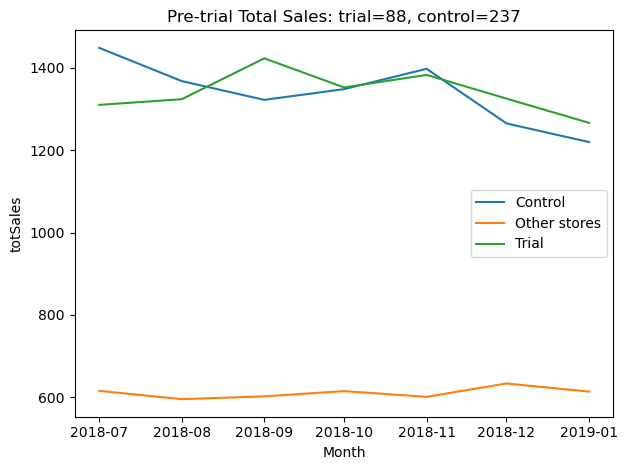

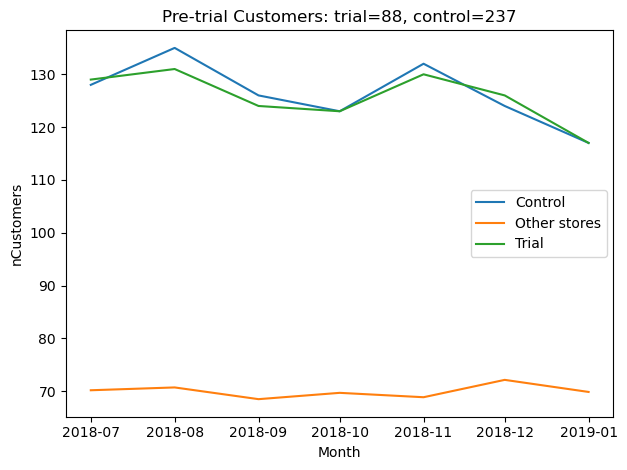

In [103]:
trial_store = 88
control_store=237
tmp = monthly.copy()
# 复制一份月度数据，避免改动原表

tmp["Store_type"] = np.where(
    tmp[STORE_COL] == trial_store, "Trial",
    np.where(tmp[STORE_COL] == control_store, "Control", "Other stores")
)
# 给每条记录打标签：Trial / Control / Other（其他门店）

tmp2 = tmp[tmp["YEARMONTH"] < PRETRIAL_END].copy()
# 只保留 pre-trial 时段，用于“选control的合理性”可视化检查

tmp2["Month"] = pd.to_datetime(tmp2["YEARMONTH"].astype(str) + "01", format="%Y%m%d")
# 把 yyyymm 转成日期（用每月1号表示），便于画时间序列

plot_df = tmp2.groupby(["Month","Store_type"], as_index=False)[["totSales","nCustomers"]].mean()
# 按 月份 + Store_type 聚合取平均：
# Trial 只有一家所以等于它本身；
# Other stores 是很多家，平均后是一条“其他店平均线”

plt.figure()
# 新建一张图

for k, sub in plot_df.groupby("Store_type"):
    plt.plot(sub["Month"], sub["totSales"], label=k)
# 按 Store_type 分组画三条线：Trial、Control、Other

plt.title(f"Pre-trial Total Sales: trial={trial_store}, control={control_store}")
plt.xlabel("Month"); plt.ylabel("totSales")
plt.legend(); plt.tight_layout()
plt.show()
# 这一段是销售额的 pre-trial 趋势图

plt.figure()
for k, sub in plot_df.groupby("Store_type"):
    plt.plot(sub["Month"], sub["nCustomers"], label=k)
# 这一段画顾客数的 pre-trial 趋势图

plt.title(f"Pre-trial Customers: trial={trial_store}, control={control_store}")
plt.xlabel("Month"); plt.ylabel("nCustomers")
plt.legend(); plt.tight_layout()
plt.show()


In [105]:
metric = "totSales"
# 选择要评估的指标（先评估销售额）

trial_sum = monthly.loc[(monthly[STORE_COL]==trial_store) & (monthly["YEARMONTH"] < PRETRIAL_END), metric].sum()
# trial 店在 pre-trial 期间的该指标总和（作为基准）

ctrl_sum  = monthly.loc[(monthly[STORE_COL]==control_store) & (monthly["YEARMONTH"] < PRETRIAL_END), metric].sum()
# control 店在 pre-trial 期间的该指标总和

scaling = trial_sum / ctrl_sum
# 缩放因子：让 control_scaled ≈ trial（在 pre-trial 总体水平一致）

scaling
# 输出 scaling


1.001558330664959

In [107]:
trial_series = monthly.loc[monthly[STORE_COL]==trial_store, ["YEARMONTH", metric]].rename(columns={metric:"trial"})
# 取 trial 店每月的 metric，并把列名改为 trial

ctrl_series  = monthly.loc[monthly[STORE_COL]==control_store, ["YEARMONTH", metric]].rename(columns={metric:"control"})
# 取 control 店每月的 metric，并把列名改为 control

comp = trial_series.merge(ctrl_series, on="YEARMONTH", how="inner").sort_values("YEARMONTH")
# 按月份把 trial 和 control 合并成一张表（只保留两者都有的月份）

comp["control_scaled"] = comp["control"] * scaling
# 把 control 按 scaling 缩放，得到可比的 control_scaled

comp["percentageDiff"] = (comp["control_scaled"] - comp["trial"]).abs() / comp["control_scaled"].replace(0, np.nan)
# 计算绝对百分比差：|control_scaled - trial| / control_scaled
# replace(0, NaN) 避免分母为0

comp.head()
# 看前几行确认计算结果


,YEARMONTH,trial,control,control_scaled,percentageDiff
0,201807,1310.0,1448.4,1450.657086,0.096961
1,201808,1323.8,1367.8,1369.931485,0.033674
2,201809,1423.0,1322.2,1324.260425,0.074562
3,201810,1352.4,1348.3,1350.401097,0.001480
4,201811,1382.8,1397.6,1399.777923,0.012129


In [109]:
pre_mask = comp["YEARMONTH"] < PRETRIAL_END
# 标记哪些行属于 pre-trial（月）

std_dev = comp.loc[pre_mask, "percentageDiff"].std(ddof=1)
# pre-trial 的 percentageDiff 标准差（样本标准差 ddof=1）
# 用它表示“正常波动大小”

n_pre = pre_mask.sum()
# pre-trial 一共有多少个月（样本量）

t_95 = stats.t.ppf(0.95, df=max(n_pre-1, 1))
# t 分布 95% 分位数（右尾），自由度=月数-1（更通用，不写死7）

std_dev, n_pre, t_95
# 输出这三个值，方便检查
trial_mask = (comp["YEARMONTH"] >= TRIAL_START) & (comp["YEARMONTH"] <= TRIAL_END)
# 标记试点期（月）

trial_check = comp.loc[trial_mask, ["YEARMONTH","percentageDiff"]].copy()
# 取出试点期的百分比差

trial_check["tValue"] = trial_check["percentageDiff"] / (std_dev if std_dev!=0 else np.nan)
# tValue = percentageDiff / std_dev（用“波动标准差”做标准化）
# 如果 std_dev=0，则设为 NaN 避免除0

trial_check["Significant(>t95)"] = trial_check["tValue"] > t_95
# 如果 tValue > t_95，就标记为“显著超出正常波动”

trial_check




,YEARMONTH,percentageDiff,tValue,Significant(>t95)
7,201902,0.026147,0.781270,False
8,201903,0.220743,6.595668,True
9,201904,0.193060,5.768527,True


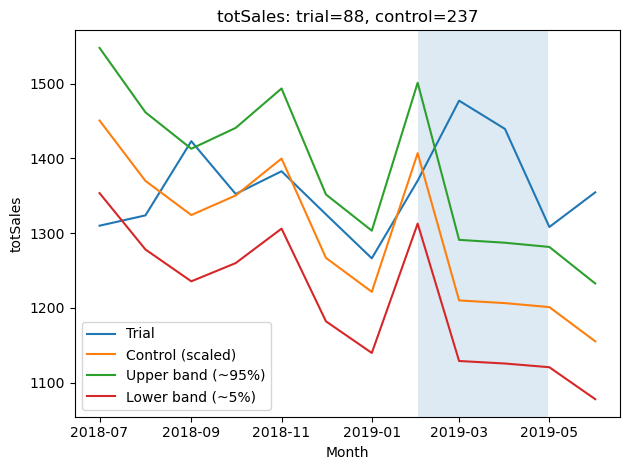

In [111]:
comp["Month"] = pd.to_datetime(comp["YEARMONTH"].astype(str) + "01", format="%Y%m%d")
# 把 yyyymm 转成每月1号日期，方便画折线图

upper = comp["control_scaled"] * (1 + 2*std_dev)
lower = comp["control_scaled"] * (1 - 2*std_dev)
# 用 ±2*std_dev 构造一条“近似置信带”（模板风格，便于可视化）

plt.figure()
plt.plot(comp["Month"], comp["trial"], label="Trial")
# 画 trial 真实值

plt.plot(comp["Month"], comp["control_scaled"], label="Control (scaled)")
# 画缩放后的 control 作为对照基线

plt.plot(comp["Month"], upper, label="Upper band (~95%)")
plt.plot(comp["Month"], lower, label="Lower band (~5%)")
# 画上下界（可视化“正常范围”）

start = pd.to_datetime(str(TRIAL_START) + "01", format="%Y%m%d")
end   = pd.to_datetime(str(TRIAL_END)   + "01", format="%Y%m%d") + pd.offsets.MonthEnd(0)
# 把试点开始月、结束月转成日期范围（end 加到月末）

plt.axvspan(start, end, alpha=0.15)
# 用浅色区域标出试点期间（Feb–Apr）

plt.title(f"{metric}: trial={trial_store}, control={control_store}")
plt.xlabel("Month"); plt.ylabel(metric)
plt.legend(); plt.tight_layout()
plt.show()
# 输出图：看 trial 是否明显偏离 control_scaled 的置信带

In [113]:
metric = "nCustomers"

trial_sum = monthly.loc[(monthly[STORE_COL]==trial_store) & (monthly["YEARMONTH"] < PRETRIAL_END), metric].sum()
ctrl_sum  = monthly.loc[(monthly[STORE_COL]==control_store) & (monthly["YEARMONTH"] < PRETRIAL_END), metric].sum()
scaling = trial_sum / ctrl_sum

trial_series = monthly.loc[monthly[STORE_COL]==trial_store, ["YEARMONTH", metric]].rename(columns={metric:"trial"})
ctrl_series  = monthly.loc[monthly[STORE_COL]==control_store, ["YEARMONTH", metric]].rename(columns={metric:"control"})

comp = trial_series.merge(ctrl_series, on="YEARMONTH", how="inner").sort_values("YEARMONTH")
comp["control_scaled"] = comp["control"] * scaling
comp["percentageDiff"] = (comp["control_scaled"] - comp["trial"]).abs() / comp["control_scaled"].replace(0, np.nan)

pre_mask = comp["YEARMONTH"] < PRETRIAL_END
std_dev = comp.loc[pre_mask, "percentageDiff"].std(ddof=1)
n_pre = pre_mask.sum()
t_95 = stats.t.ppf(0.95, df=max(n_pre-1, 1))

trial_mask = (comp["YEARMONTH"] >= TRIAL_START) & (comp["YEARMONTH"] <= TRIAL_END)
trial_check = comp.loc[trial_mask, ["YEARMONTH","percentageDiff"]].copy()
trial_check["tValue"] = trial_check["percentageDiff"] / (std_dev if std_dev!=0 else np.nan)
trial_check["Significant(>t95)"] = trial_check["tValue"] > t_95

trial_check

,YEARMONTH,percentageDiff,tValue,Significant(>t95)
7,201902,0.010281,1.387456,False
8,201903,0.132448,17.873693,True
9,201904,0.072727,9.814423,True
